### **Import Packages**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### **Define Data and Functions**

In this section, we define the data and functions necessary for plotting. For demonstration purposes, I have manually defined the data using a `pd.DataFrame()`function. The data represents the respondents' perception about the direction of flood-water entering into a village. Our aim is to plot a single rose diagram showing the current directions and multiple rose diagrams showing changes in flood-water directions.

In [20]:
# DEFINE DATA

# Data for Single Plot
current_total = pd.DataFrame({
    'Direction': ['East', 'West', 'North', 'South', 'Northeast', 'Northwest', 'Southeast', 'Southwest'],
    'Total (%)': [
        19.31, 3.2, 41.81, 5.16, 5.5,23.14,3.05, 1.2  # Percentage of Total Responses
        ]
})

# Direction Change Data for Multiplot
direction_changes = pd.DataFrame({
    'Current Direction': [
        'East', 'East', 'East', 'East', 'East',
        'West', 'West', 'West', 'West', 'West',
        'North', 'North', 'North', 'North', 'North', 'North',
        'South', 'South', 'South'
    ],
    'Past Direction': [
        'East', 'West', 'North', 'South', 'Northwest',
        'East', 'West', 'North', 'Northwest', 'Southwest',
        'East', 'West', 'North', 'South', 'East', 'Northwest',
        'East', 'West', 'South'
    ],
    'Total (%)': [
        66.00, 18.00, 6.00, 8.00, 2.00,
        15.79, 36.84, 5.26, 21.05, 21.05,          # Percentage of Total Responses
        3.85, 25.00, 55.77, 7.69, 1.92, 3.85,
        50.00, 8.33, 41.67
    ]
})


In [21]:
# DEFINE FUNCTIONS

# Convert Direction Labels to Angles
"""
Function => direction_to_angle (direction)
parameter: direction is the column of the dataframe where direction values are stored as strings
returns the angle corresponding to the direction

"""

def direction_to_angle(direction):
    angle_dict = {
        'North': 90, 'Northeast': 45, 'East': 0, 'Southeast': 315,
        'South': 270, 'Southwest': 225, 'West': 180, 'Northwest': 135
    }
    return np.deg2rad(angle_dict.get(direction, 0))

### **Plot Diagrams**

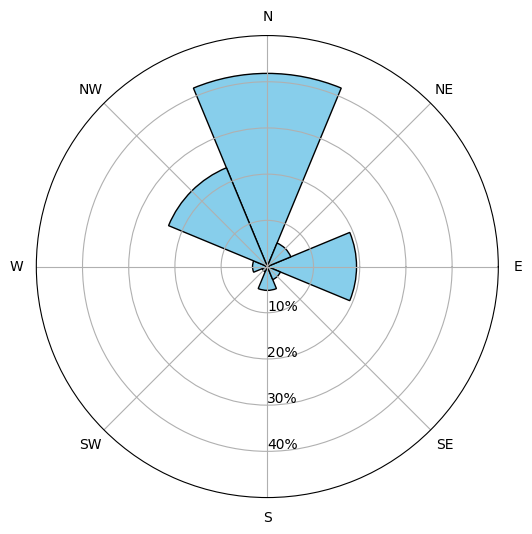

<Figure size 640x480 with 0 Axes>

In [28]:
# PLOT SINGLE ROSE DIAGRAM

# Store the Angles and Values from the Data
angles = [direction_to_angle(d) for d in current_total['Direction']]
values = current_total['Total (%)']

# Plot the Rose Diagram
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6,6))
bars = ax.bar(angles, values, width=np.deg2rad(45), color='skyblue', edgecolor='black')

# Rose Diagram or Polar Plot Formatting
ax.set_theta_zero_location('E')  # Set 0° to East Direction
ax.set_theta_direction(1)       # Set Direction Clockwise

# Set Direction Labels according to Angles
ax.set_thetagrids(range(0, 360, 45), labels=['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])

# Radial Intervals Limits
r_ticks = [10, 20, 30, 40] # Label Ticks for the Radial Lines
ax.set_rgrids(r_ticks, labels=[f"{r}%" for r in r_ticks], angle=90)
ax.set_rlim(0, 50)  # Set the Limit of Radial Lines (Here, only 5 lines will be shown)
ax.set_rlabel_position(-90) # Show the Value Labels in the Lower Quadrant. By default it is Placed in the Upper Quadrant

plt.show()

# Export High Resolution Image
save_path = ''
plt.savefig(save_path, dpi=800, bbox_inches='tight',facecolor='white')

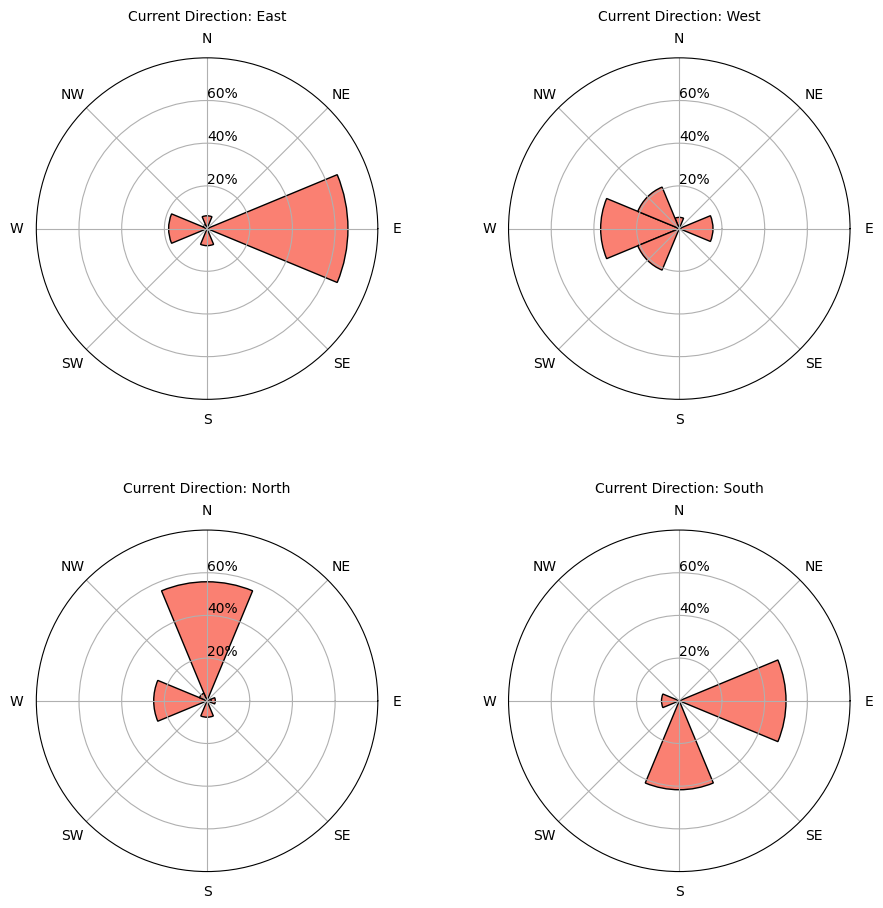

<Figure size 640x480 with 0 Axes>

In [29]:
# PLOT MULTIPLE ROSE DIAGRAMS

# Extract the Unique Current Direction Names that we need to Convert into Anlges
unique_current_dir = direction_changes['Current Direction'].unique()

# Define the Grid Layout (number of rows, columns, axes and figure size)
n_cols = 2
n_rows = int(np.ceil(len(unique_current_dir) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, subplot_kw={'projection': 'polar'}, figsize=(10, 10))
axes = axes.flatten()

# Plot Each Current Direction
for i, current_dir in enumerate(unique_current_dir):
    ax = axes[i]

    # Filter the Names of Current Direction from the Unique Sets
    subset = direction_changes[direction_changes['Current Direction'] == current_dir]

    # Store the Angles and Values from the Data
    angles = [direction_to_angle(d) for d in subset['Past Direction']]
    values = subset['Total (%)']

    # Plot the Bars or Values
    ax.bar(angles, values, width=np.deg2rad(45), color='salmon', edgecolor='black')

    # Rose Diagram or Polar Plot Formatting
    ax.set_theta_zero_location('E')  # Set 0° to East Direction
    ax.set_theta_direction(1)         # Set Direction Clockwise
    ax.set_thetagrids(range(0, 360, 45), labels=['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE']) # Set Direction Labels according to Angles

    # Radial Intervals Limits
    r_ticks = [20, 40, 60] # Label Ticks for the Radial Lines
    ax.set_rgrids(r_ticks, labels=[f"{r}%" for r in r_ticks], angle=90)
    ax.set_rlim(0, 80)    # Set the Limit of Radial Lines (Here, only 5 lines will be shown)

    # Set the Title Mentioning the Current Direction
    ax.set_title(f"Current Direction: {current_dir}", va='bottom', fontsize=10, pad=25)

plt.tight_layout(pad=4.0, w_pad=4.0, h_pad=4.0)

plt.show()

# Export High Resolution Image
save_path = ''
plt.savefig(save_path, dpi=800, bbox_inches='tight',facecolor='white')
